IMPORTING LIBRARIES

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import  mean_absolute_error, mean_squared_error, r2_score, mean_squared_error
import pickle
import numpy as np

In [2]:
df = pd.read_csv("C:\\Users\\ruchi\\notebooks\\cleaned_house_data.csv", encoding="latin1")


In [3]:
df.head(10)

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,city,statezip,year
0,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,123,374553.080247,2014
1,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,185,320321.675575,2014
2,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,286,600544.375179,2014
3,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,235,637554.852314,2014
4,490000.0,2.0,1.00,880,6380,1.0,0,0,3,880,0,1938,1994,1573,595085.747908,2014
5,335000.0,2.0,2.00,1350,2560,1.0,0,0,3,1350,0,1976,0,235,637554.852314,2014
6,640000.0,4.0,2.00,1520,6200,1.5,0,0,3,1520,0,1945,2010,1573,595085.747908,2014
7,463000.0,3.0,1.75,1710,7320,1.0,0,0,3,1710,0,1948,1994,36,379379.228341,2014
8,588500.0,3.0,1.75,2330,14892,1.0,0,0,3,1970,360,1980,0,175,613280.414185,2014
9,365000.0,3.0,1.00,1090,6435,1.0,0,0,4,1090,0,1955,2009,1573,299749.851490,2014


In [4]:
X = df.drop("price", axis=1)
y = df["price"]

TRAINING THE MODEL

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

CREATING A PIPELINE

In [6]:
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", RandomForestRegressor())
])

In [7]:
# Training the pipeline 

pipeline.fit(X_train, y_train)

,steps,"[('scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2


In [8]:
#predict

y_pred = pipeline.predict(X_test)

In [9]:

results = pd.DataFrame({
    "Actual Price": y_test,
    "Predicted Price": y_pred
})

print(results.head(10))

      Actual Price  Predicted Price
1070      530000.0    546685.750000
354       583000.0    660942.633333
881       199000.0    276894.691429
196       249000.0    280223.778590
3518      300000.0    408374.663333
3182      256000.0    277266.000000
1812      571000.0    597886.300000
1569      392500.0    413080.670000
1029      306000.0    286091.000000
1362      735000.0    633520.160000


In [10]:
#Calculating error

results["Error"] = results["Actual Price"] - results["Predicted Price"]
print(results.head(10))

      Actual Price  Predicted Price          Error
1070      530000.0    546685.750000  -16685.750000
354       583000.0    660942.633333  -77942.633333
881       199000.0    276894.691429  -77894.691429
196       249000.0    280223.778590  -31223.778590
3518      300000.0    408374.663333 -108374.663333
3182      256000.0    277266.000000  -21266.000000
1812      571000.0    597886.300000  -26886.300000
1569      392500.0    413080.670000  -20580.670000
1029      306000.0    286091.000000   19909.000000
1362      735000.0    633520.160000  101479.840000


In [11]:

print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 Score:", r2_score(y_test, y_pred))
print("MSE:",mean_squared_error(y_test,y_pred))

MAE: 73213.00254446297
RMSE: 112855.09829478028
R2 Score: 0.7228249264326246
MSE: 12736273211.12452


VISUALIZATION

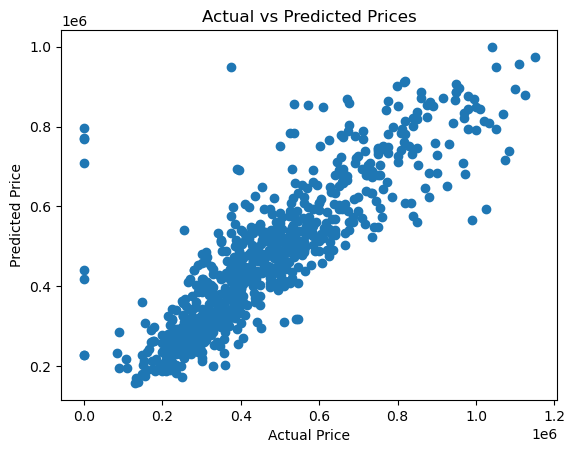

In [12]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices")
plt.show()

In [13]:
# Testing the model with a new sample house

new_data = pd.DataFrame({
    "bedrooms": [3],
    "bathrooms": [2.0],
    "sqft_living": [1800],
    "sqft_lot": [8500],
    "floors": [1.0],
    "waterfront": [0],
    "view": [0],
    "condition": [4],
    "sqft_above": [1200],
    "sqft_basement": [600],
    "yr_built": [1998],
    "yr_renovated": [0],
    "city": [200],
    "statezip": [350000],
    "year": [2014]
})

In [14]:
prediction = pipeline.predict(new_data)

print("Predicted Price:", prediction[0])

Predicted Price: 297913.21845238


In [ ]:
Load the model

In [15]:
with open("model_pipeline.pkl", "wb") as f:
    pickle.dump(pipeline, f)

Save the trained pipeline 

In [16]:
with open("model_pipeline.pkl", "rb") as f:
    model = pickle.load(f)

Make predictions with the Loaded model

In [20]:
predictions = model.predict(X_test)

print(predictions[:10])

[546685.75       660942.63333333 276894.69142856 280223.77858974
 408374.66333333 277266.         597886.3        413080.67
 286091.         633520.16      ]
